In [1]:
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

model_dt = DecisionTreeRegressor()

model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

In [3]:
mse = mean_squared_error(y_test, y_pred_dt)
mae = mean_absolute_error(y_test, y_pred_dt)
r2 = r2_score(y_test, y_pred_dt)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")

MSE: 9.17827027027027
MAE: 1.818918918918919
R2 Score: 0.8938445092392875


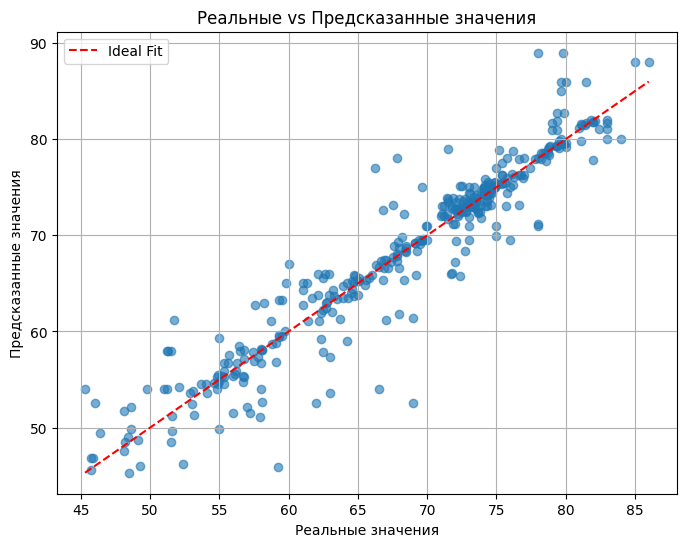

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Ideal Fit')
plt.title("Реальные vs Предсказанные значения")
plt.xlabel("Реальные значения")
plt.ylabel("Предсказанные значения")
plt.legend()
plt.grid(True)

plt.savefig(r"C:\Users\kseni\PycharmProjects\tpu-8e21-ai-basis\Fomina\jupyter\models\tree\1.png", dpi=300, bbox_inches="tight")
plt.show()

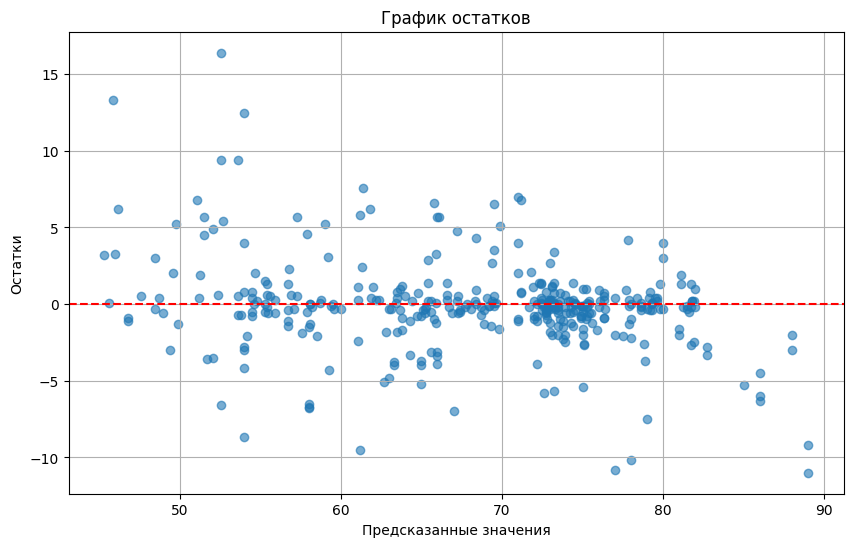

In [5]:
residuals = y_test.values.flatten() - y_pred_dt.flatten()

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_dt, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков')
plt.grid(True)

plt.savefig(r"C:\Users\kseni\PycharmProjects\tpu-8e21-ai-basis\Fomina\jupyter\models\tree\2.png", dpi=300, bbox_inches="tight")
plt.show()

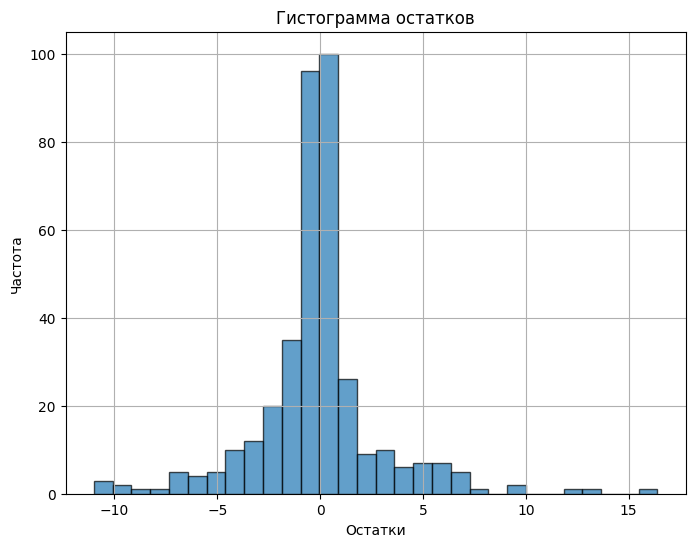

In [6]:
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title("Гистограмма остатков")
plt.xlabel("Остатки")
plt.ylabel("Частота")
plt.grid(True)

plt.savefig(r"C:\Users\kseni\PycharmProjects\tpu-8e21-ai-basis\Fomina\jupyter\models\tree\3.png", dpi=300, bbox_inches="tight")
plt.show()

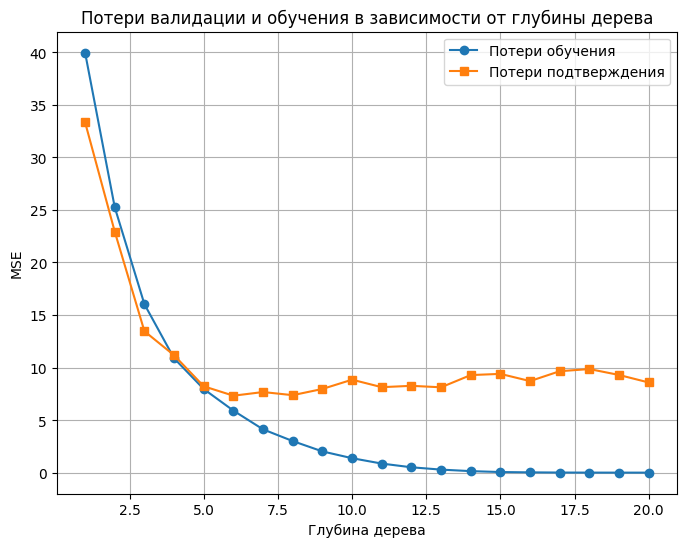

In [7]:
train_losses = []
val_losses = []

for max_depth in range(1, 21):
    temp_model = DecisionTreeRegressor(max_depth=max_depth)
    temp_model.fit(X_train, y_train)
    train_loss = mean_squared_error(y_train, temp_model.predict(X_train))
    val_loss = mean_squared_error(y_test, temp_model.predict(X_test))
    train_losses.append(train_loss)
    val_losses.append(val_loss)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 21), train_losses, marker='o', label='Потери обучения')
plt.plot(range(1, 21), val_losses, marker='s', label='Потери подтверждения')
plt.title('Потери валидации и обучения в зависимости от глубины дерева')
plt.xlabel('Глубина дерева')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

plt.savefig(r"C:\Users\kseni\PycharmProjects\tpu-8e21-ai-basis\Fomina\jupyter\models\tree\4.png", dpi=300, bbox_inches="tight")
plt.show()

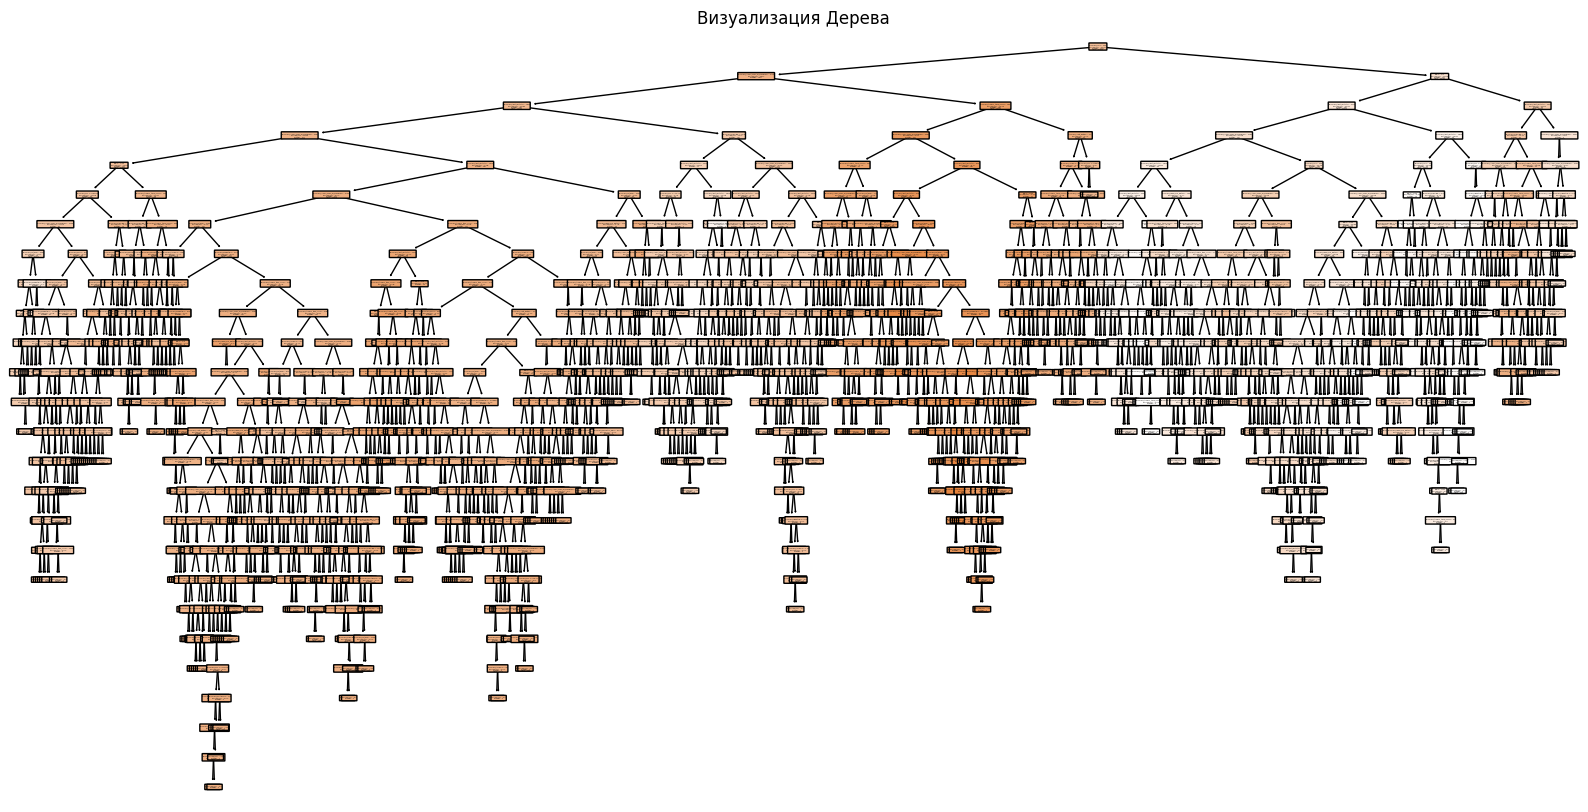

In [8]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
plt.figure(figsize=(20, 10))
plot_tree(
    model_dt,
    feature_names=X_train.columns,
    filled=True,
    rounded=True
)
plt.title("Визуализация Дерева")

plt.savefig(r"C:\Users\kseni\PycharmProjects\tpu-8e21-ai-basis\Fomina\jupyter\models\tree\5.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
import json

metrics = {
    "MAE": mae,
    "MSE": mse,
    "R2": r2
}

with open(r"C:\Users\kseni\PycharmProjects\tpu-8e21-ai-basis\Fomina\jupyter\metrics\tree_metrics.json", "w") as f:
    json.dump(metrics, f)

In [10]:
import pickle

with open(r"C:\Users\kseni\PycharmProjects\tpu-8e21-ai-basis\Fomina\jupyter\models\tree_model.pkl", "wb") as f:
    pickle.dump(model_dt, f)